# **(Modelling and Evaluating)**

## Objectives

* Answer business requirement: The client is interested in identifying non malignant and malignant skin cancer in patients through a machine learning application, used as a second opinion.

* Hypothesis 1: The dataset is balanced between malignant and non-malignant classes.

## Inputs

* inputs/skin_cancer_dataset/test
* inputs/skin_cancer_dataset/train
* inputs/skin_cancer_dataset/Validation

## Outputs

* Plot of image distribution in train, validation, and testing sets
* Image Augmentation
* ML Model creation and training
* Learning curve plot for model performance
* Model evaluation pkl file
* Prediction on a random image file

## Additional Comments

* No additional comments

---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory
  
We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()


In [1]:
import os
current_dir = os.getcwd()
current_dir

'/workspaces/skin-cancer-detector/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/workspaces/skin-cancer-detector'

# Data Directories

## Input Directories

Set train, validation, and test paths so machine knows where the data is

In [4]:
my_data_dir = 'inputs/skin_cancer_dataset'
train_path = my_data_dir + '/train'
val_path = my_data_dir + '/validation'
test_path = my_data_dir + '/test'

## Output Directories

Set output directories so machine knows where to place the outputs

In [5]:
version = 'v1'
file_path = f'outputs/{version}'

if 'outputs' in os.listdir(current_dir) and version in os.listdir(current_dir + '/outputs'):
    print('Old version is already available create a new version.')
    pass
else:
    os.makedirs(name=file_path)


Old version is already available create a new version.


## Set Label Names

In [6]:
labels = os.listdir(train_path)
print('Label for the images are', labels)

Label for the images are ['malignant', 'benign']


## Image distribution (train, validation, test sets)

We are plotting distribution to know how well the images are distributed(this code was taken from the walkthrough lesson for the malaria detector)

* train - malignant: 1047 images
* train - benign: 1260 images
* validation - malignant: 149 images
* validation - benign: 180 images
* test - malignant: 301 images
* test - benign: 360 images




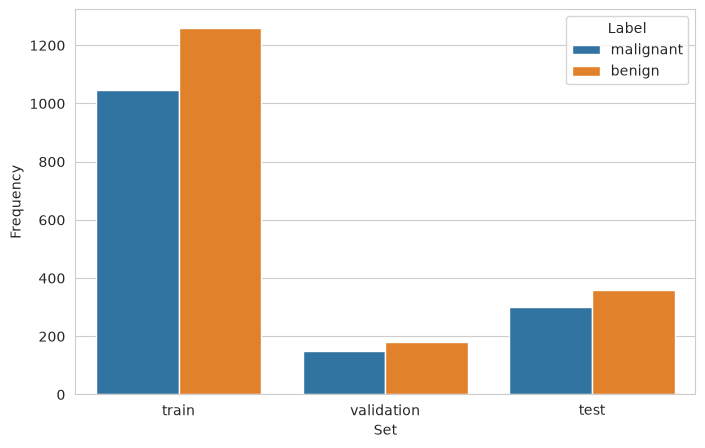

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

data = {
    'Set': [],
    'Label': [],
    'Frequency': []
}

# Define the number of rows you want to create
folders = ['train', 'validation', 'test']

# Loop to dynamically create and append rows to the dictionary
for folder in folders:
    for label in labels:
        row = {
            'Set': folder,
            'Label': label,
            'Frequency': int(len(os.listdir(my_data_dir + '/' + folder + '/' + label)))  
        }
        for key, value in row.items():
            data[key].append(value)
        print(
            f"* {folder} - {label}: {len(os.listdir(my_data_dir+'/'+ folder + '/' + label))} images")

# Convert the dictionary to a DataFrame
df_freq = pd.DataFrame(data)

print("\n")
sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))
sns.barplot(data=df_freq, x='Set', y='Frequency', hue='Label')
plt.savefig(f'{file_path}/labels_distribution.png',
            bbox_inches='tight', dpi=150)
plt.show()

There is less than a 10% difference in the number of images for each label across the train, validation, and test sets. This indicates that the dataset is well-balanced, which is beneficial for training a machine learning model.

---

## Image Augmentation

Here we will augment image data. Although it is not strictly necessary here, it is needed.

In [8]:
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # This hides the GPU from TensorFlow

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

I0000 00:00:1788444332.868343    3734 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788444353.739192    3734 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788444366.879501    3734 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


importing ImageDataGenerator to be able to augment data. Then, we will initialize the image data generator

In [9]:
augmented_images = ImageDataGenerator(
    rotation_range=15, #reduced from 20
    width_shift_range=0.1, #reduced from 0.2
    height_shift_range=0.1, #reduced from 0.2
    shear_range=0.1, #reduced from 0.2
    zoom_range=0.1, #reduced from 0.2
    horizontal_flip=True,
    fill_mode='nearest',
    brightness_range=[0.8, 1.2] # less extreme than [0.7, 1.3]
)

Now that we have the image generator, we will apply it to the training, validation, and testing data

Batch sizes for training data usually are in powers of 2 for training set

In [10]:
batch_size = 16
train_set = augmented_images.flow_from_directory(
    directory=train_path,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True
)

train_set.class_indices

Found 2307 images belonging to 2 classes.


{'benign': 0, 'malignant': 1}

Now we do it for the validation images

In [11]:
validation_set = ImageDataGenerator(rescale=1.0/255.0).flow_from_directory(
    directory=val_path,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

validation_set.class_indices

Found 329 images belonging to 2 classes.


{'benign': 0, 'malignant': 1}

And finally, we do it to the testing images

In [12]:
test_set = ImageDataGenerator(rescale=1.0/255.0).flow_from_directory(
    directory=test_path,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

test_set.class_indices

Found 661 images belonging to 2 classes.


{'benign': 0, 'malignant': 1}

Now, we create the model!

---

## Machine Learning Model

Import model packages

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Dense, Conv2D, MaxPooling2D
from tensorflow.keras import layers, regularizers, models
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam




## The model

In [36]:
def create_model():
    model = models.Sequential()

    # Input scaling
    model.add(layers.Rescaling(1./255, input_shape=(128, 128, 3)))  # 128x128 to reduce pixels

    # BLOCK 1 (16 filters)
    model.add(layers.Conv2D(16, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    
    # BLOCK 2 (32 filters)
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    
    # BLOCK 3 (64 filters) 
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    # CLASSIFIER
    model.add(layers.GlobalAveragePooling2D())  # Outputs 64 numbers
    
    # head (32 neurons)
    model.add(layers.Dense(32, activation='relu',)) # reduced to 32(from 64)
    model.add(layers.Dropout(0.7))  # increased to 0.7 for more regularization
    model.add(layers.Dense(1, activation='sigmoid'))

    # Standard optimizer - NO clipping
    optimizer = Adam(learning_rate=1e-4)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    
    return model

Now we see a summary of the model

In [37]:
create_model().summary()

/home/cistudent/.local/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,697 (100.38 KB)

 Trainable params: 25,697 (100.38 KB)

 Non-trainable params: 0 (0.00 B)

Early stopping to prevent overfitting

In [38]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

Fitting model for training

In [39]:
model = create_model()
model.fit(train_set,
          epochs=30,
          steps_per_epoch= len(train_set),
          validation_data=validation_set,
          validation_steps= len(validation_set),
          callbacks=[early_stop],
          class_weight={0:1.0, 1:2.0}, # Adjust the weights to balance the classes
          verbose=1
          )

Epoch 1/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 95s 645ms/step - accuracy: 0.4824 - loss: 0.9870 - val_accuracy: 0.4529 - val_loss: 0.6942
Epoch 2/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 91s 629ms/step - accuracy: 0.4755 - loss: 0.9650 - val_accuracy: 0.4529 - val_loss: 0.6959
Epoch 3/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 93s 638ms/step - accuracy: 0.5262 - loss: 0.9392 - val_accuracy: 0.4529 - val_loss: 0.7042
Epoch 4/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 140s 623ms/step - accuracy: 0.5782 - loss: 0.8993 - val_accuracy: 0.4529 - val_loss: 0.7302
Epoch 5/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 145s 647ms/step - accuracy: 0.6472 - loss: 0.8678 - val_accuracy: 0.4529 - val_loss: 0.7801
Epoch 6/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 141s 640ms/step - accuracy: 0.7078 - loss: 0.8066 - val_accuracy: 0.4529 - val_loss: 0.8918
Epoch 7/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 97s 666ms/step - accuracy: 0.7287 - loss: 0.7729 - val_accuracy: 0.4529 - val_loss: 1.0437
Epoch 8/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 139s 649ms/step - accuracy: 0.7412 - los

In [ ]:
model.save('outputs/v1/cancer_detector_model.h5')

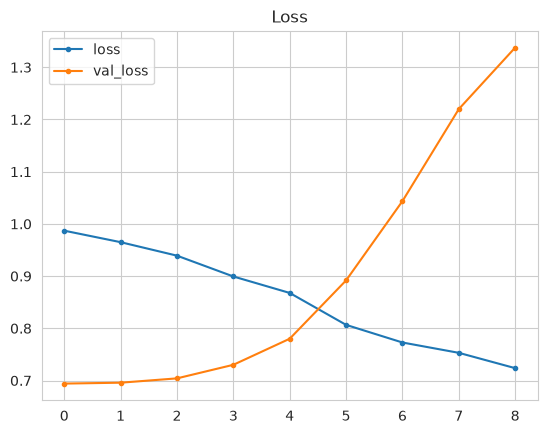

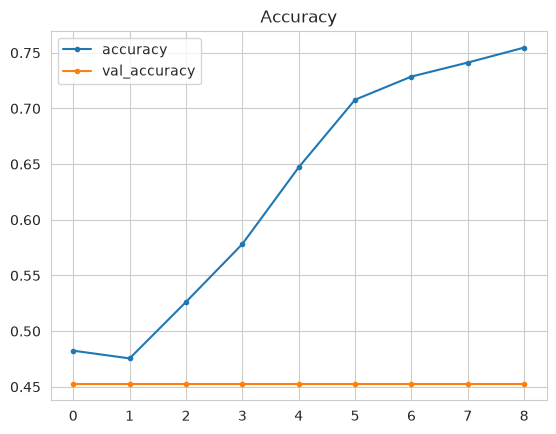

In [40]:
losses = pd.DataFrame(model.history.history)

sns.set_style("whitegrid")
losses[['loss', 'val_loss']].plot(style='.-')
plt.title("Loss")
plt.savefig(f'{file_path}/model_training_losses.png',
            bbox_inches='tight', dpi=150)
plt.show()

print("\n")
losses[['accuracy', 'val_accuracy']].plot(style='.-')
plt.title("Accuracy")
plt.savefig(f'{file_path}/model_training_acc.png',
            bbox_inches='tight', dpi=150)
plt.show()

In [30]:
import numpy as np

# Get all validation labels
val_labels = []
for i in range(len(validation_set)):
    _, labels = validation_set[i]
    val_labels.extend(labels.flatten())

val_labels = np.array(val_labels)
benign_count = np.sum(val_labels == 0)
malignant_count = np.sum(val_labels == 1)

print(f"Validation set: {benign_count} Benign, {malignant_count} Malignant")
print(f"Benign percentage: {benign_count/len(val_labels)*100:.2f}%")
print(f"Malignant percentage: {malignant_count/len(val_labels)*100:.2f}%")

Validation set: 180 Benign, 149 Malignant
Benign percentage: 54.71%
Malignant percentage: 45.29%
